# Limpieza de datos corregida a partir de los resultados del Laboratorio 1

## 0. Instalación de librerías necesarias

In [1]:
%pip install pandas numpy openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Importación de librerías necesarias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Versión de pandas: 3.0.1
Versión de numpy: 2.4.2


## **3. Exploración de datos**

### 3.1 Carga de datos original y copia

In [4]:
df = pd.read_csv('Datos/Datos Lab 1.csv') # Importar los datos originales con pandas
df_original = df.copy() # Crear una copia del DataFrame original para referencia futura 

### 3.2 Mostrar primeras filas del DataFrame original

In [5]:
df_original.head() # Mostrar las primeras filas del DataFrame original para inspección inicial

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


### 3.3 Mostrar información general del DataFrame original y el conteo de valores nulos

In [6]:
print("==================================")
print("Información del DataFrame original:")
print("================================== \n")
print("Shape original: ", df_original.shape, "\n") # Mostrar la forma del DataFrame original para entender la cantidad de filas y columnas
df_original.info() # Mostrar información detallada del DataFrame original, incluyendo tipos de datos y conteo de valores no nulos

Información del DataFrame original:

Shape original:  (1639, 24) 

<class 'pandas.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   str    
 1   Date of Service               1639 non-null   str    
 2   Sex                           1639 non-null   str    
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   str    
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smokin

> ### Valores faltantes por variable

- **Age**: Tipo: numérica continua | Nulos: 68
- **Weight (kg)**: Tipo: numérica continua | Nulos: 73
- **Height (m)**: Tipo: numérica continua | Nulos: 61
- **BMI**: Tipo: numérica continua | Nulos: 53
- **Abdominal Circumference (cm)**: Tipo: numérica continua | Nulos: 61
- **Total Cholesterol (mg/dL)**: Tipo: numérica continua | Nulos: 68
- **HDL (mg/dL)**: Tipo: numérica continua | Nulos: 82
- **Fasting Blood Sugar (mg/dL)**: Tipo: numérica continua | Nulos: 54
- **Height (cm)**: Tipo: numérica continua | Nulos: 68
- **Waist-to-Height Ratio**: Tipo: numérica continua | Nulos: 76
- **Systolic BP**: Tipo: numérica continua | Nulos: 61
- **Diastolic BP**: Tipo: numérica continua | Nulos: 85
- **Estimated LDL (mg/dL)**: Tipo: numérica continua | Nulos: 57
- **CVD Risk Score**: Tipo: numérica continua | Nulos: 29

### 3.4 Importación del diccionario de datos para análisis detallado de cada variable

In [7]:
diccionario = pd.read_excel('Datos/DiccPacientes.xlsx') # Importar el diccionario de datos con pandas
pd.set_option('display.max_colwidth', None) # Configurar pandas para mostrar el contenido completo de las celdas del diccionario
diccionario

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arterial sistólica>/<Presión arterial diastólica>"""
9,Total Cholesterol (mg/dL),Float,Colesterol total


> ### Diccionario de datos

A partir del diccionario se identificaron los siguientes aspectos relevantes:

**Columnas redundantes detectadas:**
- `Height (m)` y `Height (cm)` representan la misma variable en distintas unidades
- `Blood Pressure (mmHg)` ya está separada en `Systolic BP` y `Diastolic BP`
- `CVD Risk Level` es la versión categórica de `CVD Risk Score` (target leakage)

**Columnas no relevantes para el modelo:**
- `Patient ID` es un identificador único, no aporta información predictiva
- `Date of Service` es la fecha de atención, no tiene relación con el riesgo cardiovascular

**Variables objetivo:**
- `CVD Risk Score` es la variable que vamos a predecir (numérica continua)
- `CVD Risk Level` es su versión categórica, debe excluirse del modelo

### 3.5 Descripción estadistica de cada variable

In [8]:
df.describe() # Mostrar estadísticas descriptivas de las variables numéricas para entender su distribución y detectar posibles anomalías

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


> ### Estadísticas descriptivas

A partir de `df.describe()` se identificaron los siguientes valores fuera de rango:

**Valores imposibles (errores de datos):**

- **BMI** | Mínimo: 4.31
Fisiológicamente imposible. El mínimo registrado mundialmente es ~7.5.
Se convertirá a NaN.

- **Total Cholesterol (mg/dL)** | Mínimo: -1.25
Fisiológicamente imposible. El colesterol no puede ser negativo.
Se convertirá a NaN.

- **HDL (mg/dL)** | Mínimo: 0.008
Fisiológicamente imposible. HDL no puede ser cercano a cero.
Se convertirá a NaN todo valor menor a 10.

- **Estimated LDL (mg/dL)** | Mínimo: -92.05
Fisiológicamente imposible. LDL no puede ser negativo.
Se convertirá a NaN.

- **CVD Risk Score** | Mínimo: -20.05, Máximo: 114.98
Fuera del rango válido [0, 100].
Se convertirán a NaN los valores fuera de este rango.

- **Weight (kg)** | Mínimo: 13.26
Imposible para un adulto. Se convertirá a NaN todo valor menor a 20 kg.

- **Fasting Blood Sugar (mg/dL)** | Mínimo: 15.30
Imposible fisiológicamente. Se convertirá a NaN todo valor menor a 30.

**Outliers extremos pero posibles:**

- **Age** | Mínimo: 6.13
Inusual para un estudio cardiovascular pero no imposible. Se conserva.

- **BMI** | Máximo: 53
Obesidad mórbida extrema, posible. Se conserva.

- **CVD Risk Score** | Máximo dentro de rango: ~60
Pacientes de alto riesgo, válido. Se conserva.

### 3.6 Revisar formato de categoricas

In [9]:
categoricas = df.select_dtypes(include=['object']).columns # Identificar las columnas categóricas en el DataFrame

for i in categoricas:
    display(df[i].value_counts()) # Mostrar el conteo de valores únicos para cada columna categórica para detectar posibles errores de formato o inconsistencias

/var/folders/r4/gt1dv7gn3x7frvp7ct9s1g_h0000gn/T/ipykernel_93428/1140532580.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns # Identificar las columnas categóricas en el DataFrame


Patient ID
oSqq7069    3
gBFe4249    3
AhYt1346    3
RlsB8509    3
RwGu5647    3
           ..
ioby2183    1
mrzf5858    1
nPnN5477    1
QSFT6794    1
pDkH8432    1
Name: count, Length: 1376, dtype: int64

Date of Service
09-20-2023            6
December 05, 2025     5
04/02/2020            4
08-09-2022            4
08 Mar 22             4
                     ..
09/11/2025            1
13/08/2024            1
May 21, 2021          1
September 06, 2025    1
2021-05-01            1
Name: count, Length: 1274, dtype: int64

Sex
M    821
F    818
Name: count, dtype: int64

Blood Pressure (mmHg)
127/84    6
124/72    6
121/68    5
129/61    5
140/62    4
         ..
94/68     1
124/90    1
95/111    1
144/91    1
116/83    1
Name: count, Length: 1152, dtype: int64

...

Diabetes Status
N    821
Y    818
Name: count, dtype: int64

Physical Activity Level
High        582
Moderate    537
Low         520
Name: count, dtype: int64

Family History of CVD
N    820
Y    819
Name: count, dtype: int64

Blood Pressure Category
Hypertension Stage 2    680
Hypertension Stage 1    527
Normal                  321
Elevated                111
Name: count, dtype: int64

CVD Risk Level
HIGH            793
INTERMEDIARY    616
LOW             230
Name: count, dtype: int64

> ### Variables categóricas — Value Counts

A partir de `df.value_counts()` se analizaron las variables categóricas del dataset:

- **Patient ID:** Hay IDs repetidos, con algunos apareciendo hasta 3 veces. 
Esto sugiere registros duplicados que se analizarán a continuación para 
determinar si corresponden a visitas distintas o registros mal ingresados.

- **Date of Service:**
Se detectaron múltiples formatos de fecha inconsistentes. De todas maneras, esta columna no tiene relación con el riesgo cardiovascular de un paciente  por lo que se eliminará independientemente del formato. Algunos ejemplos de formatos encontrados:
    - 09-20-2023
    - December 05, 2025
    - 08 Mar 22
    - 2021-05-01



- **Sex:** Dos categorías balanceadas: M (821) y F (818). Sin inconsistencias.

- **Blood Pressure (mmHg):** Esta columna es redundante ya que su información está separada en 
Systolic BP y Diastolic BP.

- **Smoking Status:** Dos categorías balanceadas: Y (850) y N (789). Sin inconsistencias.

- **Diabetes Status:** Dos categorías balanceadas: N (821) e Y (818). Sin inconsistencias.

- **Physical Activity Level:** Tres categorías bien distribuidas: High (582), Moderate (537), Low (520). 
Sin inconsistencias.

- **Family History of CVD:** Dos categorías balanceadas: N (820) e Y (819). Sin inconsistencias.

- **Blood Pressure Category:** Cuatro categorías con distribución desbalanceada. Hypertension Stage 2 
domina con 680 registros mientras Elevated solo tiene 111. Sin inconsistencias 
en los valores.

- **CVD Risk Level:** Tres categorías desbalanceadas: HIGH (793), INTERMEDIARY (616), LOW (230). 
Esta columna es target leakage ya que es la versión categórica de CVD Risk 
Score, la variable objetivo.

### 3.7 Análisis extenso de duplicados y variables categoricas para determinar acciones de limpieza

In [10]:
# Total de duplicados exactos
print(f"Total filas: {len(df)}")
print(f"Duplicados exactos (todas las columnas): {df.duplicated().sum()}")

# IDs repetidos
ids_repetidos = df[df['Patient ID'].duplicated(keep=False)]
print(f"IDs únicos repetidos: {ids_repetidos['Patient ID'].nunique()}")
print(f"Filas con ID repetido: {len(ids_repetidos)}")

# Filas con ID repetido pero datos distintos
no_exactos = ids_repetidos[~ids_repetidos.duplicated(keep=False)]
print(f"Filas con ID repetido pero datos distintos: {len(no_exactos)}")

# Mostrar ejemplos
print("\nEjemplos de registros con ID repetido y datos distintos:")
print(no_exactos.sort_values('Patient ID')[
    ['Patient ID', 'Date of Service', 'Age', 'Weight (kg)', 'CVD Risk Score']
].head(20))

Total filas: 1639
Duplicados exactos (todas las columnas): 151
IDs únicos repetidos: 171
Filas con ID repetido: 434
Filas con ID repetido pero datos distintos: 132

Ejemplos de registros con ID repetido y datos distintos:
     Patient ID     Date of Service    Age  Weight (kg)  CVD Risk Score
1227   AhYt1346          09-28-2020  41.00       71.300         -13.090
383    Axab9332          2021-12-11  58.00       69.870          15.277
1117   Axab9332          2021-12-11  58.00       69.870          23.430
1469   BQvQ6431          09/11/2020  33.00      118.300          29.833
846    BqZp2317      April 15, 2025  72.00       57.836          16.872
305    BqZp2317      April 15, 2025  72.00       57.836           7.050
850    CDsa2651          23/06/2025  39.00       73.300          26.604
246    CKKa5109      March 18, 2023  51.00       85.900           6.550
523    CYeS2965           26 Jul 25  33.00      108.700          24.022
1385   ChGR7779          2022-08-29  46.00       78.700   

> ### Duplicados - Casos específicos

Se identificaron tres tipos de registros problemáticos:

**Tipo 1 — Duplicados exactos: 151 filas**
Filas completamente idénticas en todas las columnas. No aportan información
adicional al modelo. Se eliminarán con `drop_duplicates()`.

**Tipo 2 — Mismo ID, misma fecha, CVD Risk Score imposible: parte de las 132 filas**
Mismo paciente y misma visita pero con un CVD Risk Score fuera del rango
válido [0, 100], como scores negativos. El valor imposible se convertirá
a NaN primero, luego `drop_duplicates()` eliminará la fila duplicada
conservando la que tiene el score válido.

**Tipo 3 — Mismo ID, misma fecha, CVD Risk Score distinto pero ambos válidos: resto de las 132 filas**
Mismo paciente y misma visita pero con dos scores válidos distintos, como
Axab9332 con scores 15.27 y 23.43, o BqZp2317 con 16.87 y 7.05. No hay
forma de determinar cuál es el correcto, por lo que se conservará el primer
registro encontrado usando `drop_duplicates(subset=['Patient ID'], keep='first')`.

**Orden de limpieza definido:**
1. Convertir CVD Risk Score imposible a NaN
2. Eliminar duplicados exactos con `drop_duplicates()`
3. Eliminar registros con mismo ID conservando el primero con
   `drop_duplicates(subset=['Patient ID'], keep='first')`
4. Eliminar filas sin CVD Risk Score con `dropna(subset=['CVD Risk Score'])`

### 3.8 Graficos estadisticos

#### 3.8.1 Boxplots de variables numéricas para identificar outliers y rangos válidos

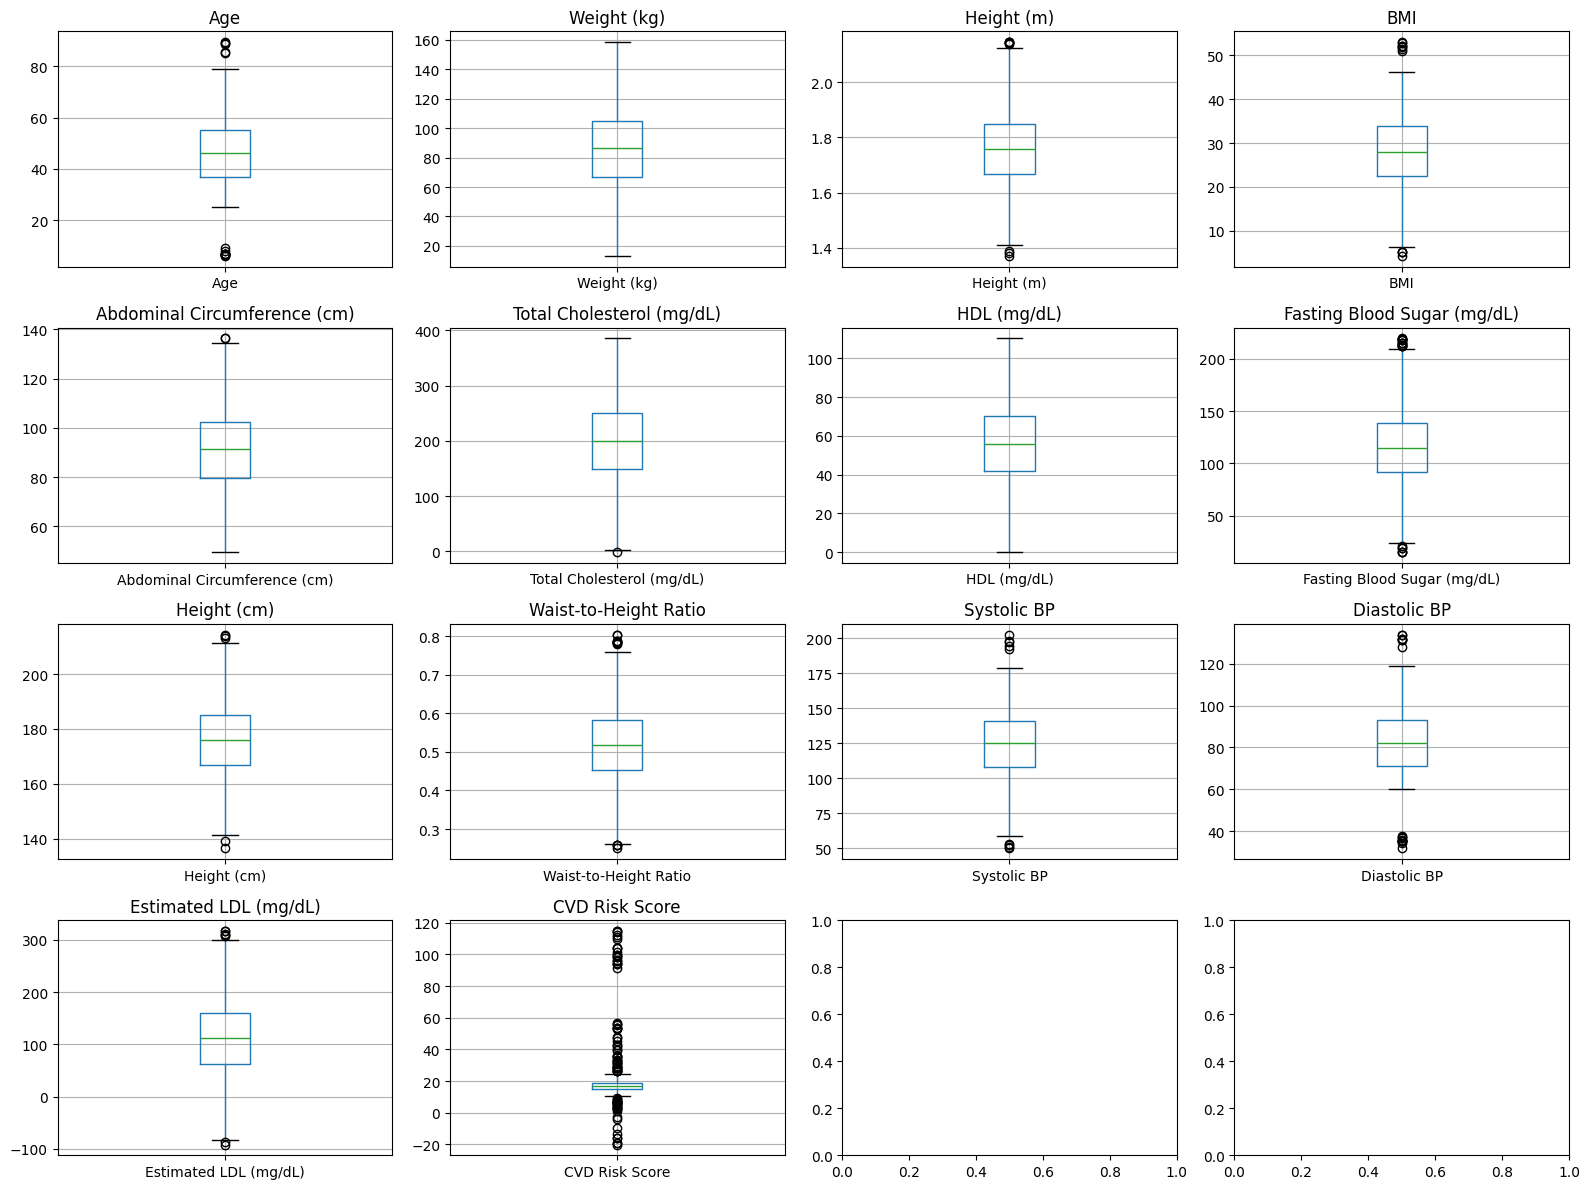

In [11]:
# Se incluyen unicamente variables numericas para los boxplots
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

> ### Observaciones — Boxplots

- **Age:**
Distribución relativamente simétrica con mediana alrededor de 46 años.
Se observan outliers en el extremo inferior (~6 años) que son inconsistentes
con el contexto del estudio, el cual se enfoca en población adulta. Se 
convertirán a NaN los valores menores a 18 años.

- **Weight (kg):**
Distribución ligeramente sesgada hacia arriba con la mayoría de valores
entre 60 y 120 kg. No se observan outliers estadísticos en el boxplot,
sin embargo en el análisis del describe se identificó un mínimo de 13 kg
que es imposible para un adulto y se tratará en la fase de limpieza.

- **Height (m):**
Distribución simétrica y sin outliers extremos. Los valores están dentro
de rangos fisiológicamente posibles.

- **BMI:**
Distribución ligeramente sesgada hacia arriba. Se observan outliers en el
extremo inferior (~4) que son fisiológicamente imposibles y se convertirán
a NaN. El máximo (~50) es alto pero posible en obesidad mórbida.

- **Abdominal Circumference (cm):**
Distribución simétrica sin outliers extremos. Todos los valores parecen
estar dentro de rangos posibles.

- **Total Cholesterol (mg/dL):**
Distribución simétrica. Se observa un outlier en el extremo inferior
cercano a 0 que es fisiológicamente imposible y se convertirá a NaN.

- **HDL (mg/dL):**
Distribución simétrica. Se observan outliers en el extremo inferior
cercanos a 0 que son fisiológicamente imposibles y se convertirán a NaN.

- **Fasting Blood Sugar (mg/dL):**
Distribución ligeramente sesgada hacia arriba. Se observan outliers en
el extremo inferior (~15) que son fisiológicamente imposibles y se
convertirán a NaN.

- **Height (cm):**
Redundante con Height (m). Se eliminará esta columna independientemente
de sus valores.

- **Waist-to-Height Ratio:**
Distribución simétrica. Se observa un outlier superior (~0.8) que es
alto pero posible. Sin valores imposibles.

- **Systolic BP:**
Distribución simétrica. Se observan outliers en ambos extremos pero
dentro de rangos posibles (~50 y ~200).

- **Diastolic BP:**
Distribución simétrica. Se observan outliers en el extremo inferior
(~35) y superior (~130) pero dentro de rangos posibles.

- **Estimated LDL (mg/dL):**
Se observan outliers claros en el extremo inferior con valores negativos
(~-100) que son fisiológicamente imposibles y se convertirán a NaN.
El máximo (~300) es alto pero posible.

- **CVD Risk Score:**
Se observan outliers en ambos extremos con valores negativos (~-20) y
superiores a 100 (~115) que están fuera del rango válido [0, 100] y se
convertirán a NaN. La distribución está sesgada hacia valores bajos con
mediana alrededor de 17.

> ### Rangos clínicamente imposibles verificados

- **Age:**
    - Mínimo posible: 18 años (contexto de estudio cardiovascular en adultos).
    - Valor en dataset: 6.13 -> se convertirá a NaN.

- **Weight (kg):**
    - Mínimo posible para un adulto: ~30 kg.
    - Valor en dataset: 13.26 -> se convertirá a NaN.

- **BMI:**
    - Mínimo registrado con supervivencia médica: ~7.8 kg/m².
    - En contexto de estudio cardiovascular ambulatorio: mínimo razonable ~10.
    - Valor en dataset: 4.31 -> se convertirá a NaN.

- **Total Cholesterol (mg/dL):**
    - Fisiológicamente imposible ser negativo o menor a 50 mg/dL.
    - Valor en dataset: -1.25 -> se convertirá a NaN.

- **HDL (mg/dL)**
    - Mínimo fisiológico documentado: ~5 mg/dL en enfermedades genéticas raras.
    - En contexto clínico práctico: valores menores a 10 son imposibles.
    - Valor en dataset: 0.008 -> se convertirá a NaN todo valor menor a 10.

- **Fasting Blood Sugar (mg/dL)**
    - Por debajo de 40 mg/dL es hipoglucemia severa potencialmente fatal.
    - Por debajo de 15 mg/dL es incompatible con la consciencia.
    - Valor en dataset: 15.30 -> se convertirá a NaN todo valor menor a 40.

- **Estimated LDL (mg/dL)**
    - Fisiológicamente imposible ser negativo.
    - Valor en dataset: -92.05 -> se convertirá a NaN.

- **Systolic BP (mmHg)**
    - Mínimo para perfusión de órganos vitales: ~70 mmHg.
    - Valor en dataset: ~49.9 -> se convertirá a NaN todo valor menor a 70.

- **Diastolic BP (mmHg)**
    - Mínimo fisiológico razonable: ~40 mmHg.
    - Valor en dataset: ~31.7 -> se convertirá a NaN todo valor menor a 40.

- **CVD Risk Score**
    - Rango válido definido: [0, 100].
    - Valores en dataset: -20.05 y 114.98 -> se convertirán a NaN.

#### 3.8.2 Histogramas de variables numéricas para analizar distribuciones y detectar sesgos o anomalías

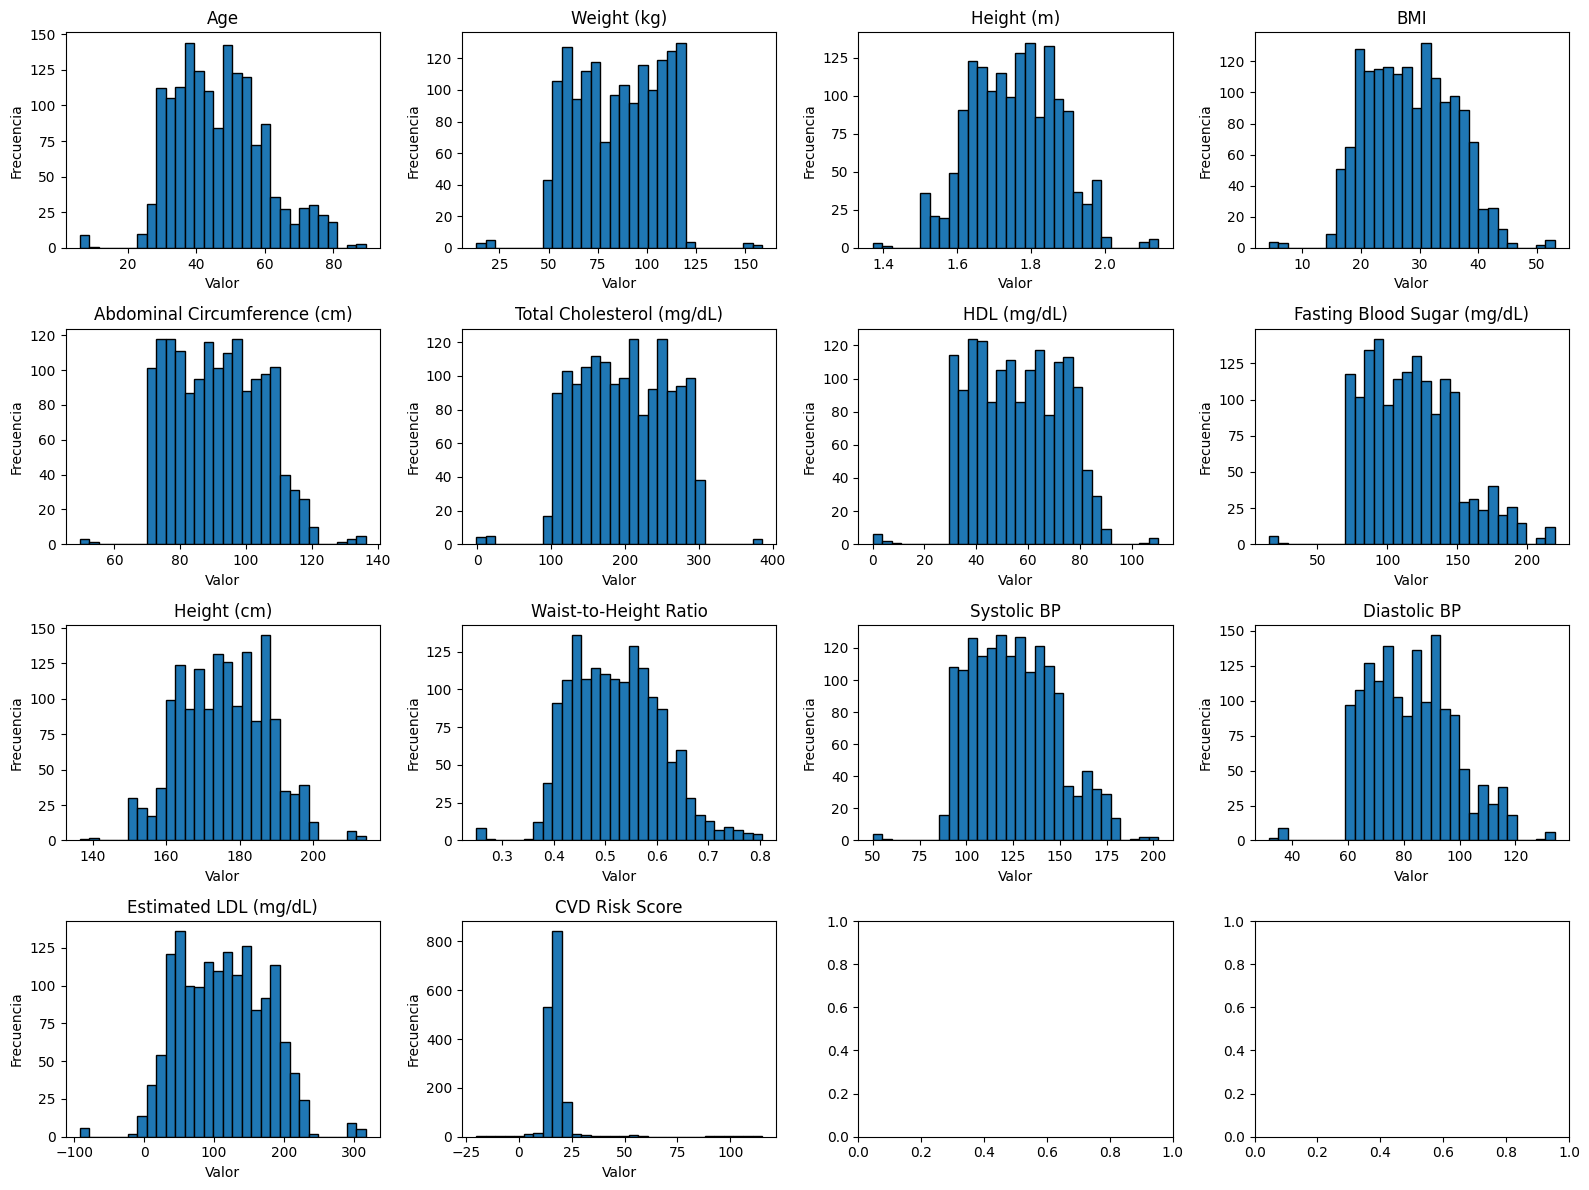

In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

> ### Observaciones — Histogramas

- **Age:**
Distribución aproximadamente normal y simétrica centrada alrededor de 
los 40-50 años. Confirma lo visto en el boxplot.

- **Weight (kg):**
Distribución aproximadamente normal con leve sesgo hacia la derecha. 
La mayoría de pacientes pesa entre 60 y 120 kg.

- **Height (m):**
Distribución normal y simétrica centrada alrededor de 1.75 m. 
Sin anomalías visibles.

- **BMI:**
Distribución normal con leve sesgo hacia la derecha. La mayoría 
de pacientes tiene BMI entre 20 y 40.

- **Abdominal Circumference (cm):**
Distribución aproximadamente normal centrada alrededor de 90 cm 
con leve sesgo hacia la derecha.

- **Total Cholesterol (mg/dL):**
Distribución aproximadamente normal centrada alrededor de 200 mg/dL. 
Se confirma la barra aislada cerca de 0 correspondiente a los valores 
imposibles ya identificados.

- **HDL (mg/dL):**
Distribución con sesgo hacia la derecha, la mayoría de valores 
concentrados entre 30 y 80 mg/dL. Se confirma la barra aislada 
cercana a 0 de los valores imposibles ya identificados.

- **Fasting Blood Sugar (mg/dL):**
Distribución aproximadamente normal centrada alrededor de 115 mg/dL 
con leve sesgo hacia la derecha. Se confirma una barra aislada 
cerca de 15 correspondiente a valores imposibles ya identificados.

- **Height (cm):**
Distribución normal centrada alrededor de 175 cm. Redundante con 
Height (m), se eliminará.

- **Waist-to-Height Ratio:**
Distribución normal y simétrica centrada alrededor de 0.5. 
Sin anomalías visibles.

- **Systolic BP:**
Distribución aproximadamente normal centrada alrededor de 125 mmHg. 
Sin anomalías visibles.

- **Diastolic BP:**
Distribución aproximadamente normal centrada alrededor de 80 mmHg 
con leve sesgo hacia la izquierda. Se confirma una barra aislada 
cerca de 35 correspondiente a valores bajos ya identificados.

- **Estimated LDL (mg/dL):**
Distribución aproximadamente normal centrada alrededor de 110 mg/dL. 
Se confirma claramente una barra aislada en valores negativos 
correspondiente a los valores imposibles ya identificados.

- **CVD Risk Score:**
Distribución con fuerte sesgo hacia la derecha, con la gran mayoría 
de pacientes concentrados entre 10 y 30 puntos. Se confirman barras 
aisladas en valores negativos correspondientes a los valores 
imposibles ya identificados. Importante tener en cuenta este sesgo 
al evaluar el modelo.

#### 3.8.3 Scatter plots de variables numéricas para analizar relaciones entre ellas y detectar patrones o anomalías

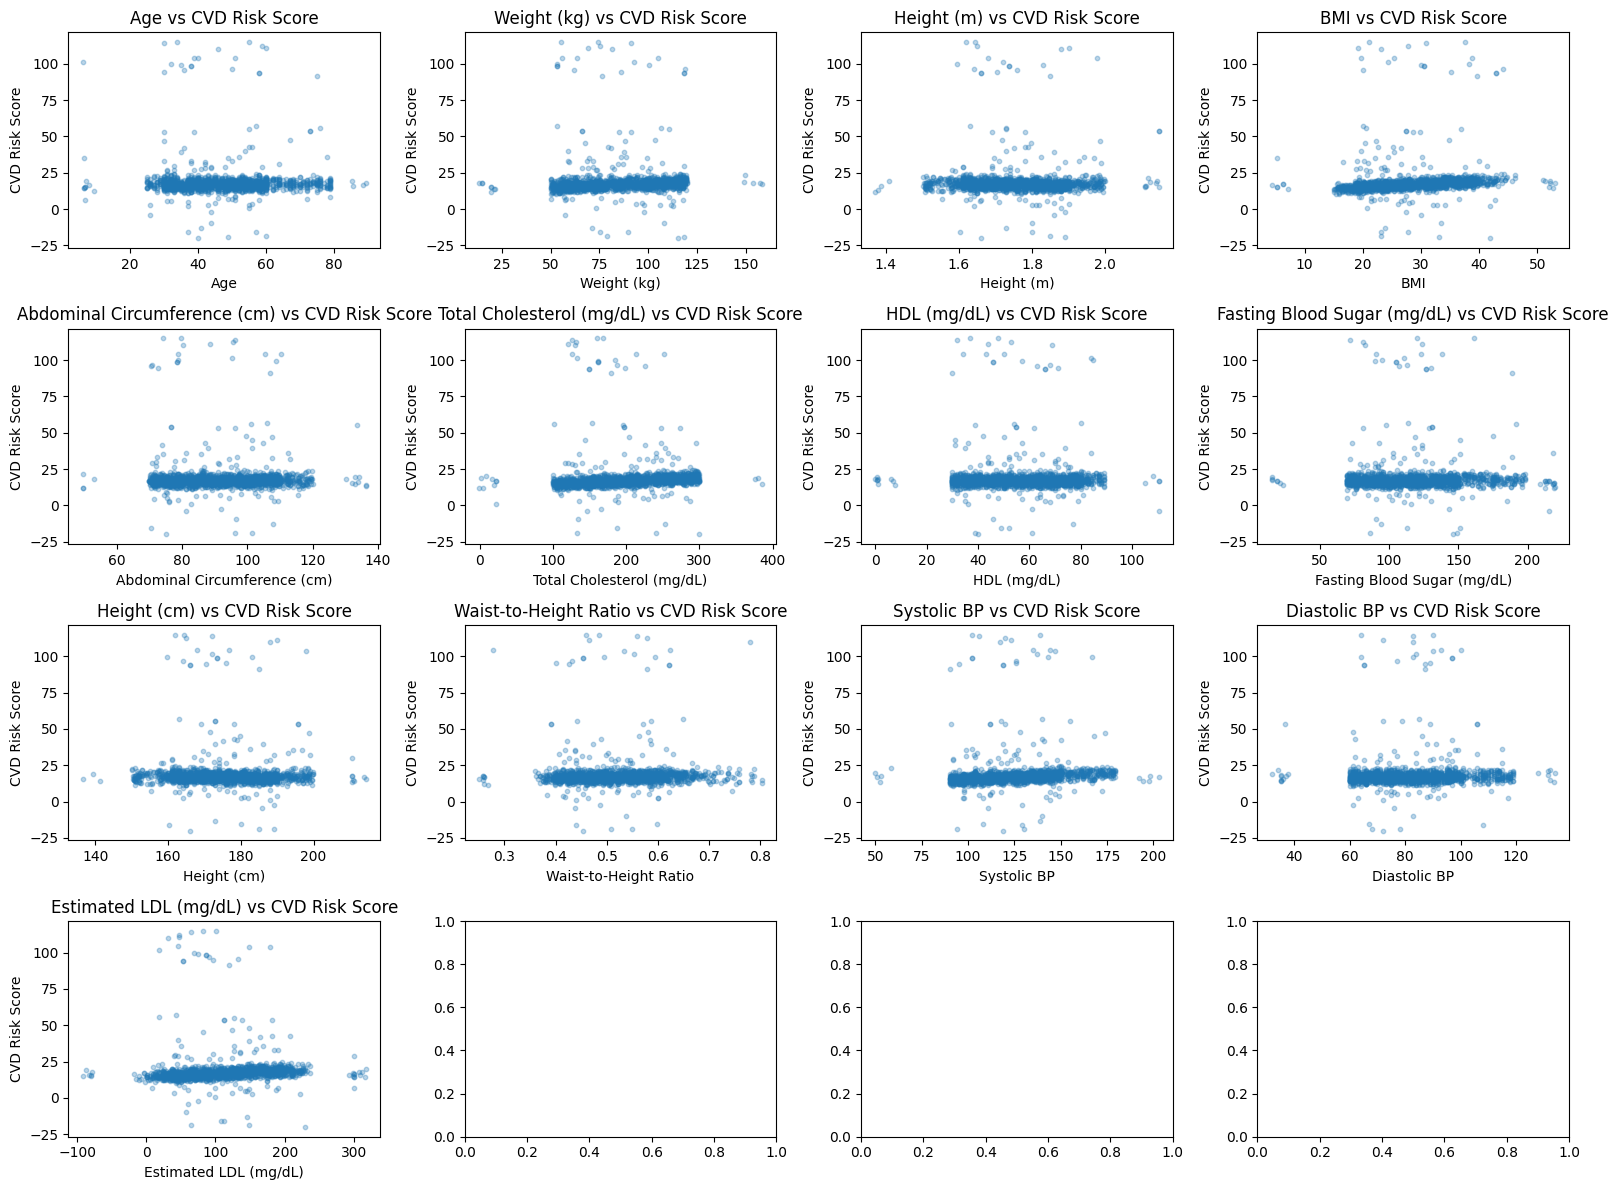

In [13]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
target = 'CVD Risk Score'

cols_to_plot = [col for col in numeric_cols if col != target]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if i < len(axes):
        axes[i].scatter(df[col], df[target], alpha=0.3, s=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('CVD Risk Score')
        axes[i].set_title(f'{col} vs CVD Risk Score')

plt.tight_layout()
plt.show()

> ### Observaciones — Scatter Plots vs CVD Risk Score

- **Age:**
No se observa una relación lineal clara. Los puntos están distribuidos 
de forma relativamente uniforme en todos los rangos de edad, aunque 
hay una leve tendencia a scores más altos en edades medias.

- **Weight (kg):**
No se observa relación lineal con el CVD Risk Score. Los puntos 
están dispersos uniformemente sin un patrón claro.

- **Height (m):**
No se observa ninguna relación con el CVD Risk Score. 
Distribución completamente aleatoria.

- **BMI:**
Leve tendencia positiva, a mayor BMI ligeramente mayor CVD Risk Score, 
pero la relación es muy débil. Confirma la correlación baja de 0.13 
vista en el análisis previo.

- **Abdominal Circumference (cm):**
Similar al BMI, leve tendencia positiva pero muy débil. 
Sin patrón lineal claro.

- **Total Cholesterol (mg/dL):**
No se observa relación lineal con el CVD Risk Score. 
Distribución uniforme en todos los rangos.

- **HDL (mg/dL):**
No se observa relación lineal clara. Los puntos están 
dispersos uniformemente.

- **Fasting Blood Sugar (mg/dL):**
No se observa relación lineal con el CVD Risk Score. 
Distribución completamente aleatoria.

- **Height (cm):**
Redundante con Height (m). Se eliminará. No se observa 
relación con el CVD Risk Score.

- **Waist-to-Height Ratio:**
No se observa relación lineal clara con el CVD Risk Score.

- **Systolic BP:**
Leve tendencia positiva, a mayor presión sistólica ligeramente 
mayor CVD Risk Score, pero la relación es muy débil.

- **Diastolic BP:**
No se observa relación lineal clara con el CVD Risk Score.

- **Estimated LDL (mg/dL):**
No se observa relación lineal con el CVD Risk Score. 
Distribución uniforme en todos los rangos.

> ### Conclusión general de los scatter plots
Ninguna variable numérica muestra una relación lineal fuerte con 
CVD Risk Score. Las correlaciones son muy débiles en todos los casos. 
Esto sugiere que las relaciones pueden ser no lineales o que el poder 
predictivo está más en las variables categóricas y en combinaciones 
de variables que en variables individuales. Esto justifica explorar 
regresión polinomial y features derivadas en el lab 2.

### 3.8.4 Gráficos de barras para variables categóricas para analizar distribuciones y detectar desbalances o anomalías

/var/folders/r4/gt1dv7gn3x7frvp7ct9s1g_h0000gn/T/ipykernel_93428/368177664.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns


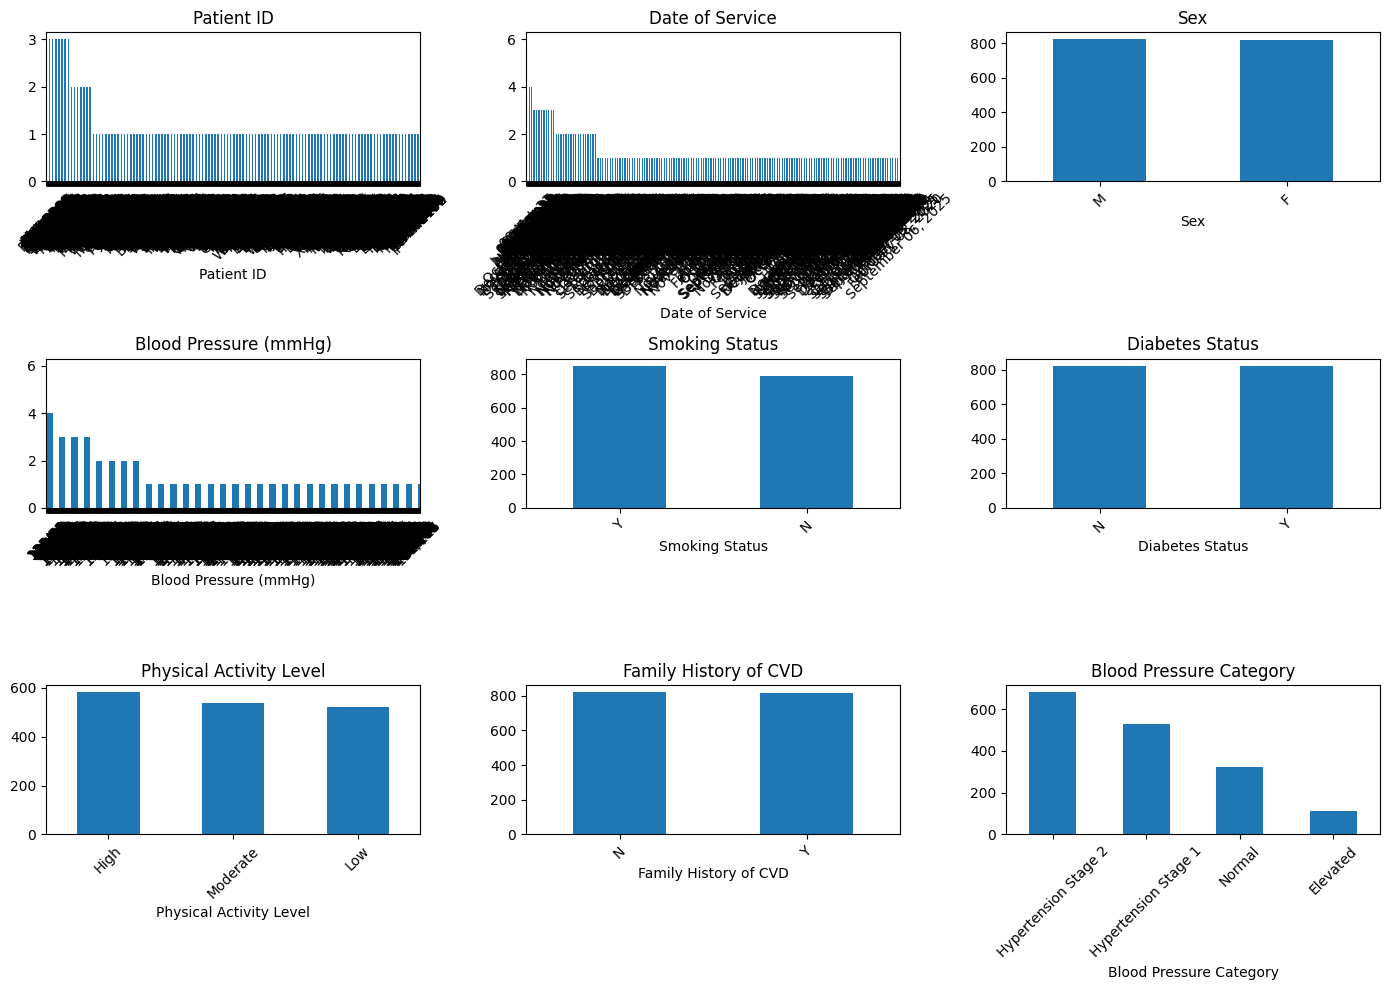

In [14]:
categoricas = df.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> ### Observaciones — Gráficas de barras categóricas

- **Patient ID y Date of Service:**
Demasiados valores únicos para ser útiles como gráficas de barras. 
Confirma que estas columnas se eliminarán.

- **Blood Pressure (mmHg):**
Al ser una combinación de dos valores numéricos en formato texto 
como "127/84", genera demasiados valores únicos y la gráfica es 
ilegible. Confirma que esta columna se eliminará y se usarán 
Systolic BP y Diastolic BP que ya están separadas.

- **Sex:**
Dos categorías perfectamente balanceadas: M (821) y F (818). 
Sin inconsistencias.

- **Smoking Status:**
Dos categorías balanceadas: Y (850) y N (789). Sin inconsistencias.

- **Diabetes Status:**
Dos categorías balanceadas: N (821) e Y (818). Sin inconsistencias.

- **Physical Activity Level:**
Tres categorías bien distribuidas: High (582), Moderate (537), 
Low (520). Sin inconsistencias.

- **Family History of CVD:**
Dos categorías balanceadas: N (820) e Y (819). Sin inconsistencias.

- **Blood Pressure Category:**
Cuatro categorías desbalanceadas. Hypertension Stage 2 domina 
con ~680 registros mientras Elevated solo tiene ~111. 
Sin inconsistencias en los valores.

## 4. Limpieza de datos